# Phase 1 — Data Exploration & Preprocessing
## SWE485: Selected Topics in Software Engineering
### King Saud University — Software Engineering Department

**Dataset:** Obesity or CVD Risk Dataset (Kaggle)  
**Target Variable:** NObeyesdad (Obesity Level — 7 classes)  
**Phase:** 1 — Problem Understanding, Data Exploration & Preprocessing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries imported successfully.')

All libraries imported successfully.


---
## 1. Introduction & Problem Statement

Obesity has become one of the most significant global health challenge
in recent years. It is closely associated with many chronic diseases 
such as cardiovascular diseases (CVD), diabetes, hypertension, and 
other metabolic disorders. These health conditions not only affect the 
quality of life of individuals but also increase the overall burden on 
healthcare systems worldwide.

Lifestyle behaviors such as eating habits, physical activity levels, 
water consumption, and daily routines play an important role in 
determining a person's body weight and overall health condition. 
However, many individuals may not fully understand how their daily 
habits and lifestyle choices contribute to weight gain and obesity risk.

**Project Goal:**  
The goal of this project is to analyze lifestyle and health-related 
data in order to explore the relationship between daily habits and 
obesity levels. By examining different behavioral and physiological 
factors, the project aims to identify key features that influence 
obesity outcomes. Based on these insights, the system aims to build 
machine learning models to predict obesity risk and provide 
personalized health advice and recommendations to help individuals 
improve their lifestyle and reduce obesity risk.


## 2. Dataset Selection & Justification

### Dataset Goal & Source
The dataset used in this project is the **Obesity or CVD Risk Dataset**,
obtained from Kaggle.

**Dataset Source:**  
https://www.kaggle.com/datasets/aravindpcoder/obesity-or-cvd-risk-classifyregressorcluster

The main purpose of this dataset is to analyze the relationship between 
lifestyle habits and obesity levels. It contains several variables related 
to individuals' demographic information, physical measurements, eating 
habits, and daily lifestyle behaviors that may influence obesity risk.

The target variable is **NObeyesdad**, which represents the obesity level 
of individuals. The dataset contains 7 classes:
- Insufficient Weight
- Normal Weight
- Overweight Level I
- Overweight Level II
- Obesity Type I
- Obesity Type II
- Obesity Type III

### Justification
This dataset was selected because:
1. It contains lifestyle and behavioral features directly related to obesity
2. It includes both numerical and categorical variables
3. It is structured in tabular format with 2,111 observations and 17 features
4. It has no missing values — making it suitable for reliable analysis
5. Classes are well balanced — suitable for classification modeling

## 3. Load the Dataset

In [3]:
df = pd.read_csv('Dataset/raw_kaggle_data.csv')

print(f'Dataset shape: {df.shape}')
print(f'\nColumn names:')
print(df.columns.tolist())
df.head()

Dataset shape: (2111, 17)

Column names:
['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 4. Initial Data Inspection

In [4]:
print('=== Data Types & Non-Null Counts ===')
print(df.info())

print('\n=== Statistical Summary ===')
print(df.describe())

print('\n=== Missing Values Per Column ===')
print(df.isnull().sum())

print('\n=== Duplicate Rows ===')
print(f'Duplicates: {df.duplicated().sum()}')

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 1


## 5. Exploratory Data Analysis (EDA)
### 5.1 Target Variable Distribution

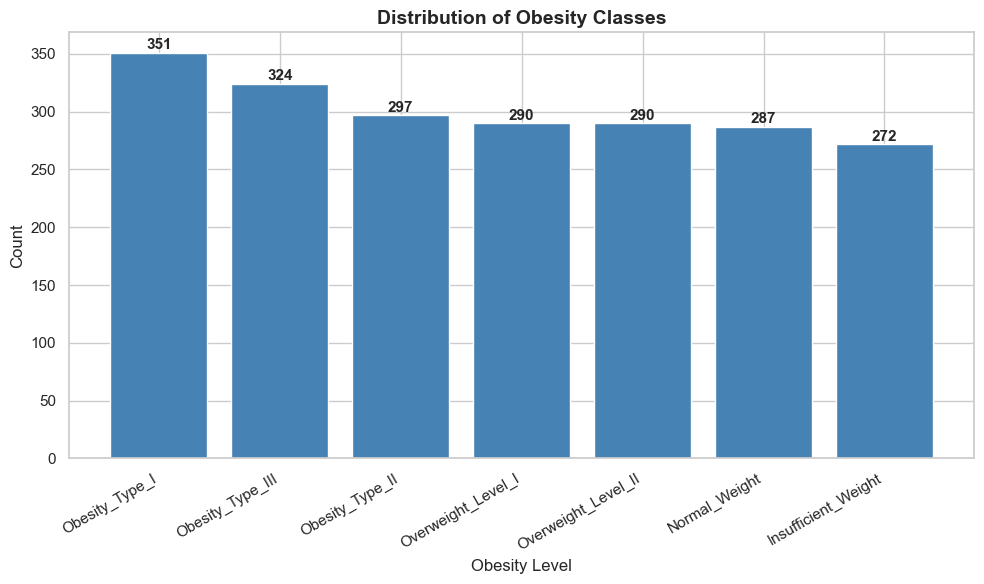

Insight: 7 well-balanced classes ranging from 267 to 351 per class.


In [5]:
plt.figure(figsize=(10, 6))
counts = df['NObeyesdad'].value_counts()
bars = plt.bar(counts.index, counts.values,
               color='steelblue', edgecolor='white')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 3,
             str(int(bar.get_height())),
             ha='center', fontsize=11, fontweight='bold')

plt.title('Distribution of Obesity Classes', fontsize=14, fontweight='bold')
plt.xlabel('Obesity Level')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/eda_class_distribution.png', dpi=150)
plt.show()
print('Insight: 7 well-balanced classes ranging from 267 to 351 per class.')

### 5.2 Feature Distributions — Histograms

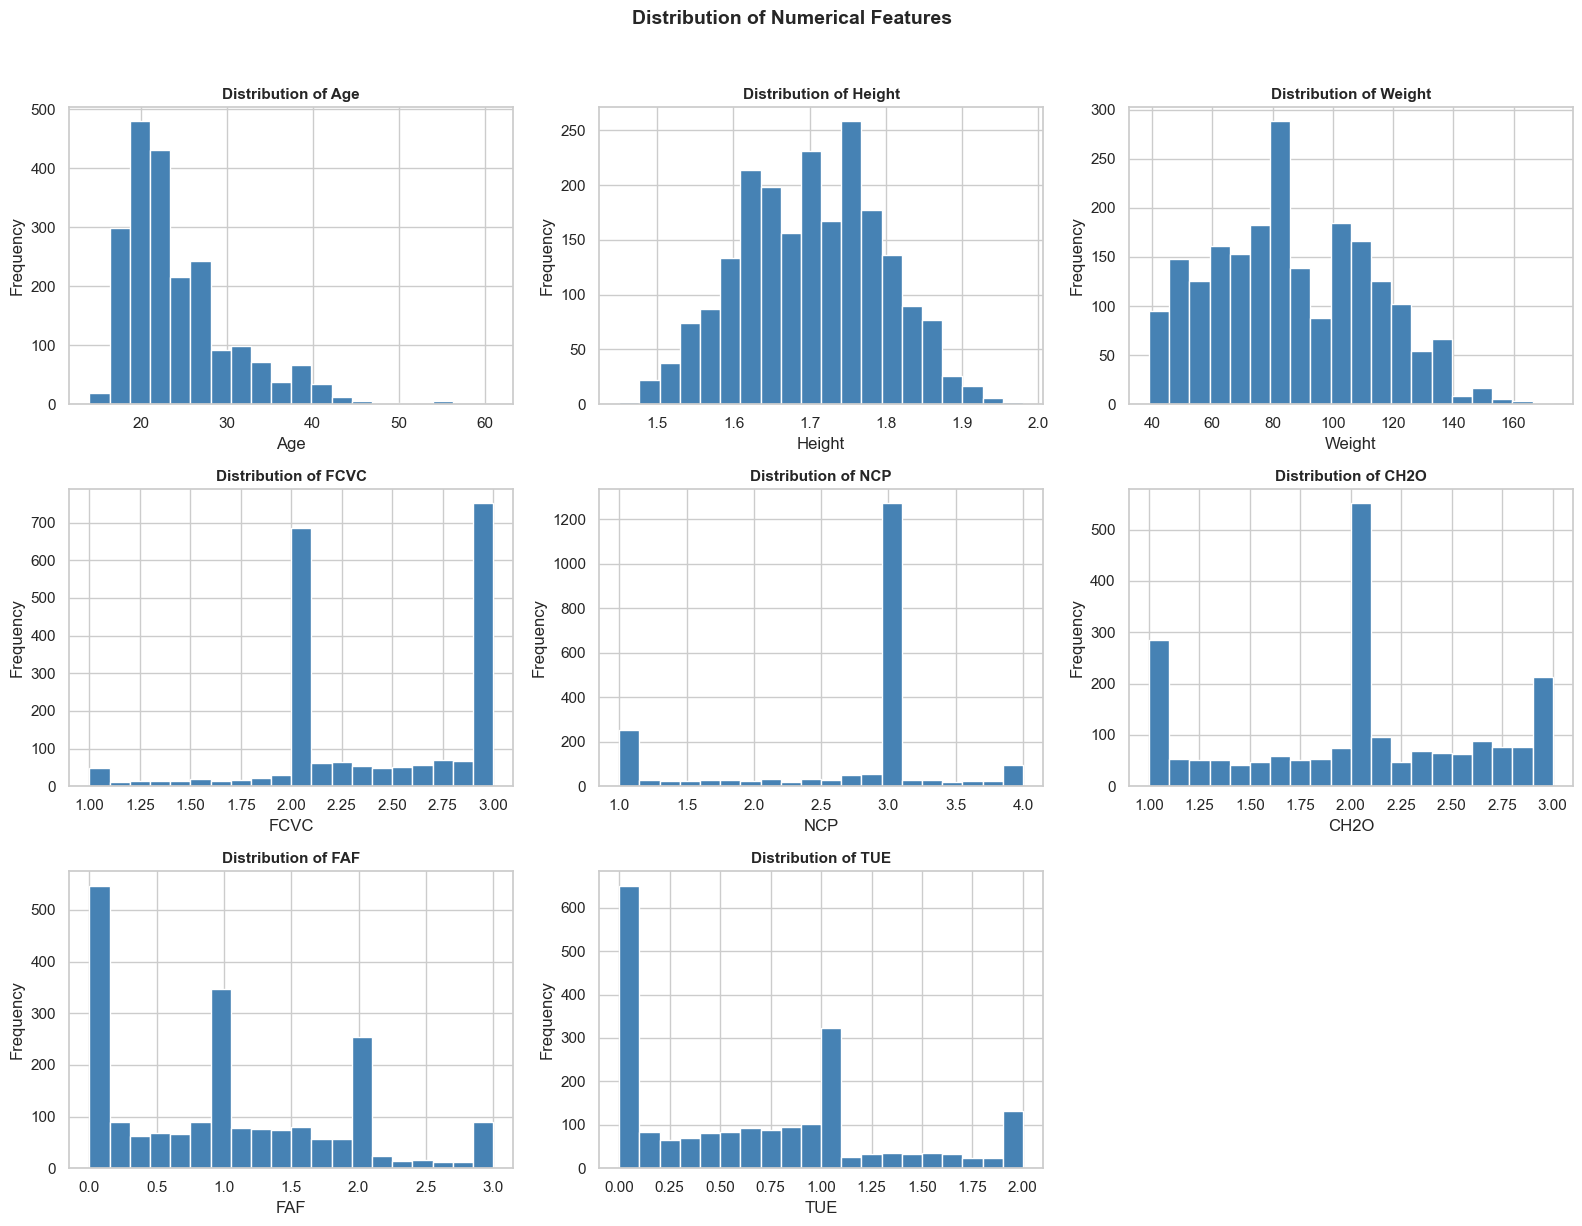

Insight: Age is right-skewed — most participants are young adults.


In [6]:
numerical_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide the last empty subplot
axes[8].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/eda_histograms.png', dpi=150)
plt.show()
print('Insight: Age is right-skewed — most participants are young adults.')

### 5.3 Feature Distributions — Boxplots

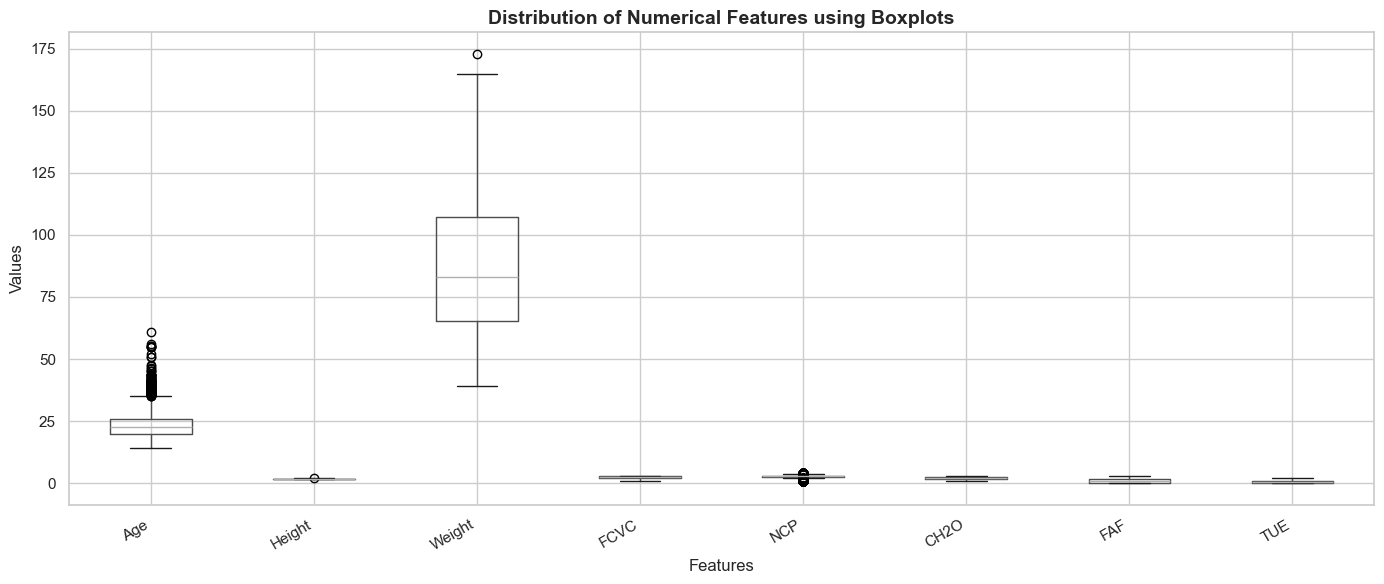

Insight: Weight shows the widest spread — high variability across individuals.


In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
df[numerical_cols].boxplot(ax=ax)
ax.set_title('Distribution of Numerical Features using Boxplots', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Features')
ax.set_ylabel('Values')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/eda_boxplots.png', dpi=150)
plt.show()
print('Insight: Weight shows the widest spread — high variability across individuals.')

### 5.4 Relationship Between Weight and Obesity Level

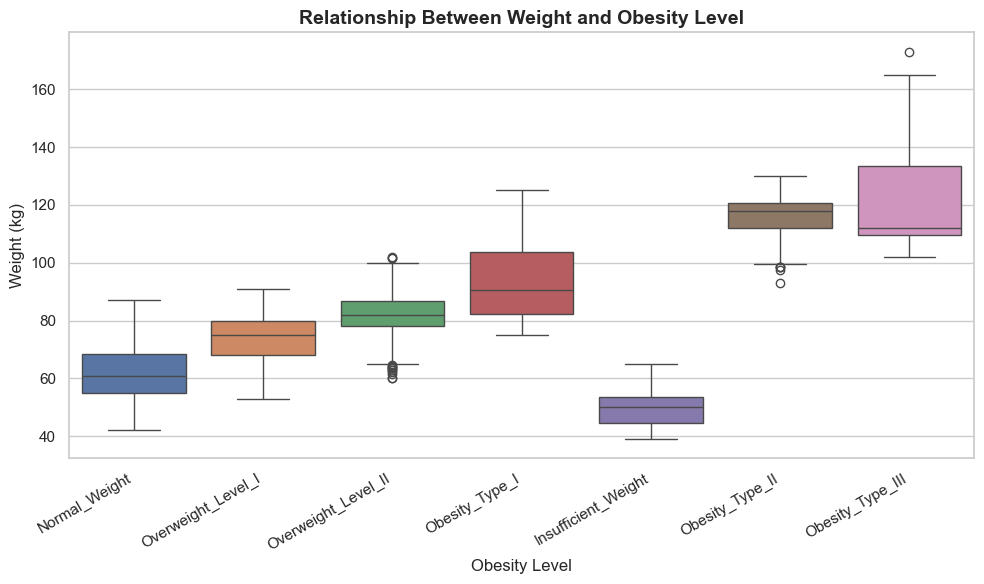

Insight: Weight increases clearly across obesity levels — a strong predictor!


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='NObeyesdad', y='Weight',
            hue='NObeyesdad', legend=False, ax=ax)
ax.set_title('Relationship Between Weight and Obesity Level',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Obesity Level')
ax.set_ylabel('Weight (kg)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/eda_weight_vs_obesity.png', dpi=150)
plt.show()
print('Insight: Weight increases clearly across obesity levels — a strong predictor!')

### 5.5 Correlation Heatmap

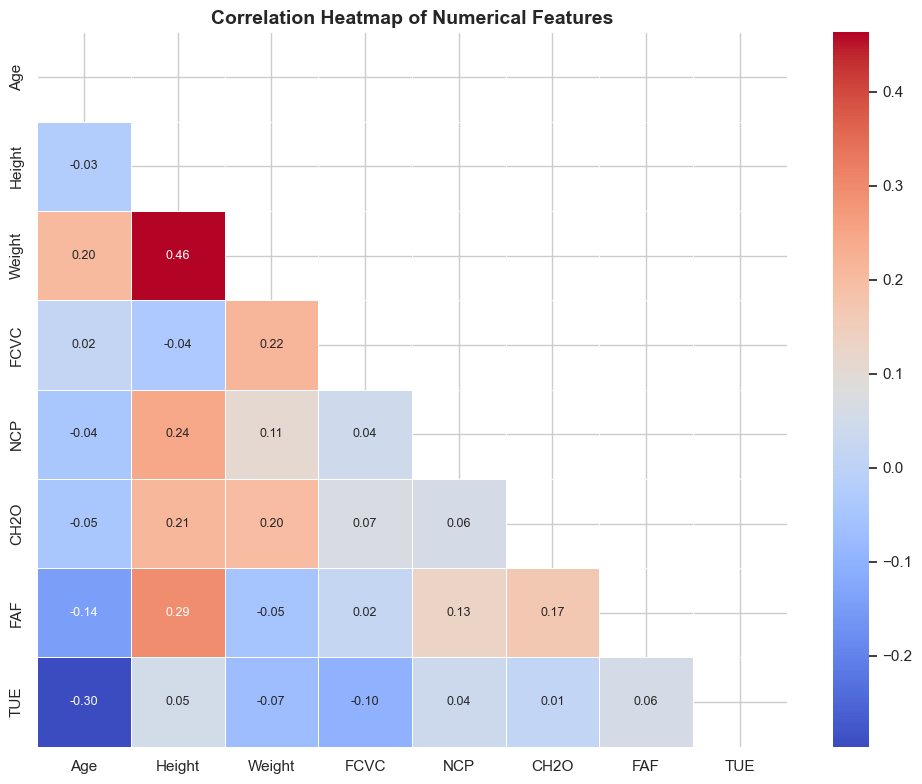

Insight: Height and Weight are positively correlated (0.46) — expected!


In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, ax=ax,
            annot_kws={'size': 9})

ax.set_title('Correlation Heatmap of Numerical Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/eda_correlation_heatmap.png', dpi=150)
plt.show()
print('Insight: Height and Weight are positively correlated (0.46) — expected!')

### 5.6 Missing Values Visualization

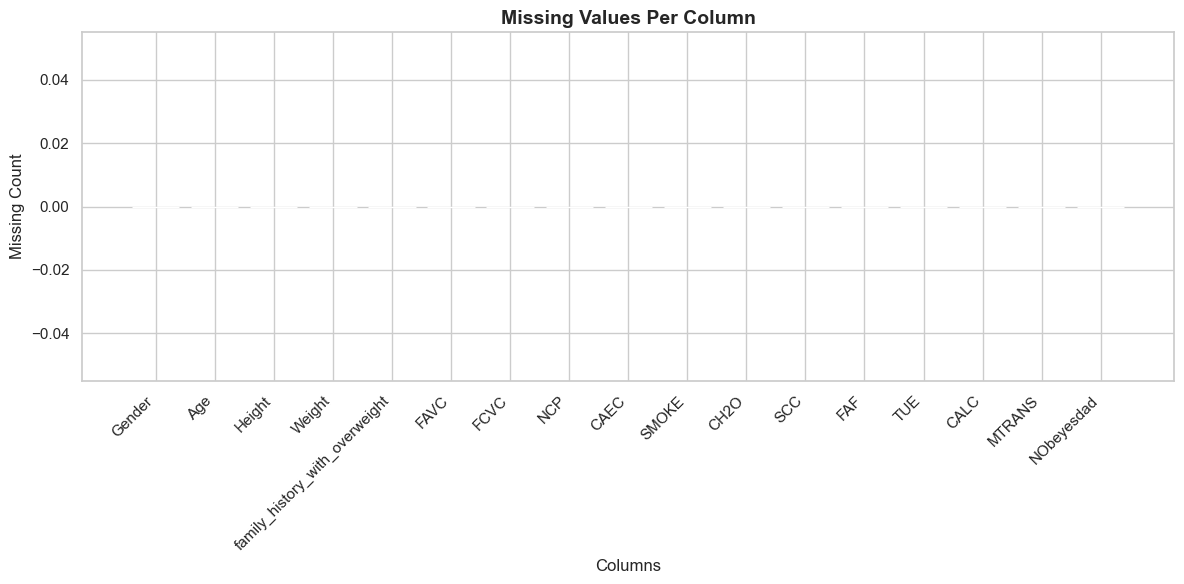

Insight: No missing values in any column — dataset is complete!


In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
missing = df.isnull().sum()
ax.bar(missing.index, missing.values, color='steelblue', edgecolor='white')
ax.set_title('Missing Values Per Column', fontsize=14, fontweight='bold')
ax.set_xlabel('Columns')
ax.set_ylabel('Missing Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/eda_missing_values.png', dpi=150)
plt.show()
print('Insight: No missing values in any column — dataset is complete!')

## 6. Preprocessing Pipeline
### 6.1 Remove Duplicate Rows

In [12]:
print(f'Rows before removing duplicates: {len(df)}')
df.drop_duplicates(inplace=True)
print(f'Rows after removing duplicates: {len(df)}')
print(f'Duplicates removed: {2111 - len(df)}')

Rows before removing duplicates: 2111
Rows after removing duplicates: 2087
Duplicates removed: 24


### 6.2 Engineer BMI Feature

In [13]:
# BMI = Weight(kg) / Height(m)^2
# Justification: BMI captures both Height and Weight in one meaningful
# ratio that directly measures obesity risk
df['BMI'] = df['Weight'] / (df['Height'] ** 2)

print('BMI feature created!')
print(df['BMI'].describe())

BMI feature created!
count    2087.000000
mean       29.765758
std         8.024934
min        12.998685
25%        24.368897
50%        28.896224
75%        36.095538
max        50.811753
Name: BMI, dtype: float64


### 6.3 Drop Height and Weight

In [14]:
# Justification: Height and Weight are now captured in BMI
# Dropping them reduces redundancy and keeps features meaningful
df.drop(columns=['Height', 'Weight'], inplace=True)

print('Height and Weight dropped!')
print(f'New shape: {df.shape}')

Height and Weight dropped!
New shape: (2087, 16)


### 6.4 Label Encode Categorical Variables

In [15]:
le = LabelEncoder()
categorical_cols = ['Gender', 'family_history_with_overweight',
                    'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC',
                    'MTRANS', 'NObeyesdad']
label_mappings = {}

for col in categorical_cols:
    df[col + '_encoded'] = le.fit_transform(df[col])
    label_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'{col}: {label_mappings[col]}')

df.drop(columns=categorical_cols, inplace=True)
print(f'\nEncoding done! New shape: {df.shape}')

Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
family_history_with_overweight: {'no': np.int64(0), 'yes': np.int64(1)}
FAVC: {'no': np.int64(0), 'yes': np.int64(1)}
CAEC: {'Always': np.int64(0), 'Frequently': np.int64(1), 'Sometimes': np.int64(2), 'no': np.int64(3)}
SMOKE: {'no': np.int64(0), 'yes': np.int64(1)}
SCC: {'no': np.int64(0), 'yes': np.int64(1)}
CALC: {'Always': np.int64(0), 'Frequently': np.int64(1), 'Sometimes': np.int64(2), 'no': np.int64(3)}
MTRANS: {'Automobile': np.int64(0), 'Bike': np.int64(1), 'Motorbike': np.int64(2), 'Public_Transportation': np.int64(3), 'Walking': np.int64(4)}
NObeyesdad: {'Insufficient_Weight': np.int64(0), 'Normal_Weight': np.int64(1), 'Obesity_Type_I': np.int64(2), 'Obesity_Type_II': np.int64(3), 'Obesity_Type_III': np.int64(4), 'Overweight_Level_I': np.int64(5), 'Overweight_Level_II': np.int64(6)}

Encoding done! New shape: (2087, 16)


### 6.5 Normalize Numerical Features

In [16]:
cols_to_normalize = ['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']

scaler = MinMaxScaler()
df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

print('Normalization done, Sample:')
df.head()

Normalization done, Sample:


,Age,FCVC,NCP,CH2O,FAF,TUE,BMI,Gender_encoded,family_history_with_overweight_encoded,FAVC_encoded,CAEC_encoded,SMOKE_encoded,SCC_encoded,CALC_encoded,MTRANS_encoded,NObeyesdad_encoded
0,0.148936,0.5,0.666667,0.5,0.000000,0.5,0.301162,0,1,0,2,0,0,3,3,1
1,0.148936,1.0,0.666667,1.0,1.000000,0.0,0.297240,0,1,0,2,1,1,2,3,1
2,0.191489,0.5,0.666667,0.5,0.666667,0.5,0.284736,1,1,0,2,0,0,1,3,1
3,0.276596,1.0,0.666667,0.5,0.666667,0.0,0.366359,1,0,0,2,0,0,1,4,5
4,0.170213,0.5,0.000000,0.5,0.000000,0.0,0.405778,1,0,0,2,0,0,2,3,6


### 6.6 Save Preprocessed Dataset

In [18]:
df.to_csv('Dataset/preprocessed_data.csv', index=False)

print('Preprocessed dataset saved')
print(f'Final shape: {df.shape}')
print(f'\nFinal columns:')
print(df.columns.tolist())

Preprocessed dataset saved
Final shape: (2087, 16)

Final columns:
['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI', 'Gender_encoded', 'family_history_with_overweight_encoded', 'FAVC_encoded', 'CAEC_encoded', 'SMOKE_encoded', 'SCC_encoded', 'CALC_encoded', 'MTRANS_encoded', 'NObeyesdad_encoded']


### 6.7 Preprocessing Visualizations

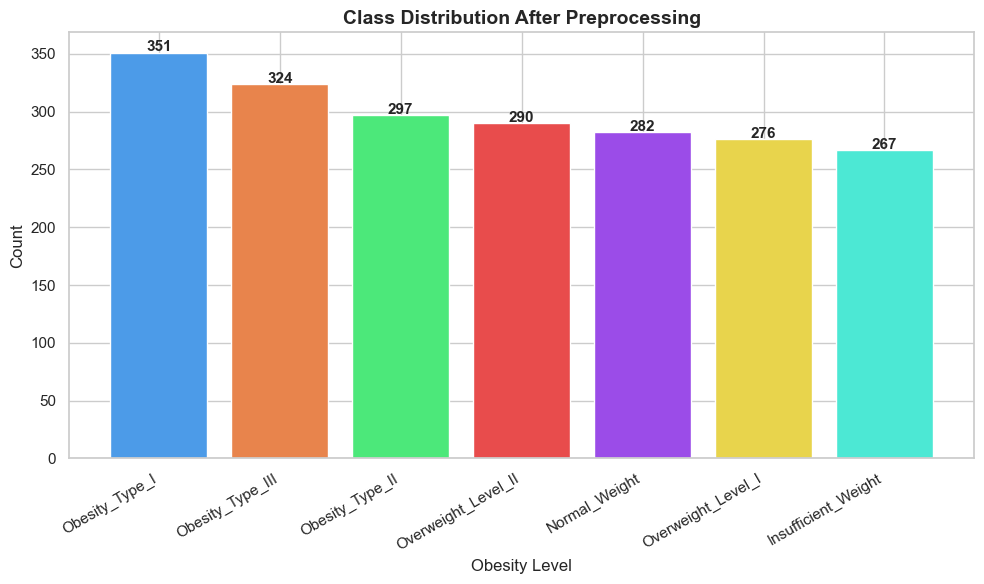

In [19]:
obesity_map = {v: k for k, v in label_mappings['NObeyesdad'].items()}
df_plot = df.copy()
df_plot['Obesity Level'] = df_plot['NObeyesdad_encoded'].map(obesity_map)

fig, ax = plt.subplots(figsize=(10, 6))
counts = df_plot['Obesity Level'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=['#4C9BE8','#E8844C','#4CE87A',
                     '#E84C4C','#9B4CE8','#E8D44C','#4CE8D4'],
              edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            str(int(bar.get_height())),
            ha='center', fontsize=11, fontweight='bold')
ax.set_title('Class Distribution After Preprocessing', fontsize=14, fontweight='bold')
ax.set_xlabel('Obesity Level')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/prep_class_distribution.png', dpi=150)
plt.show()

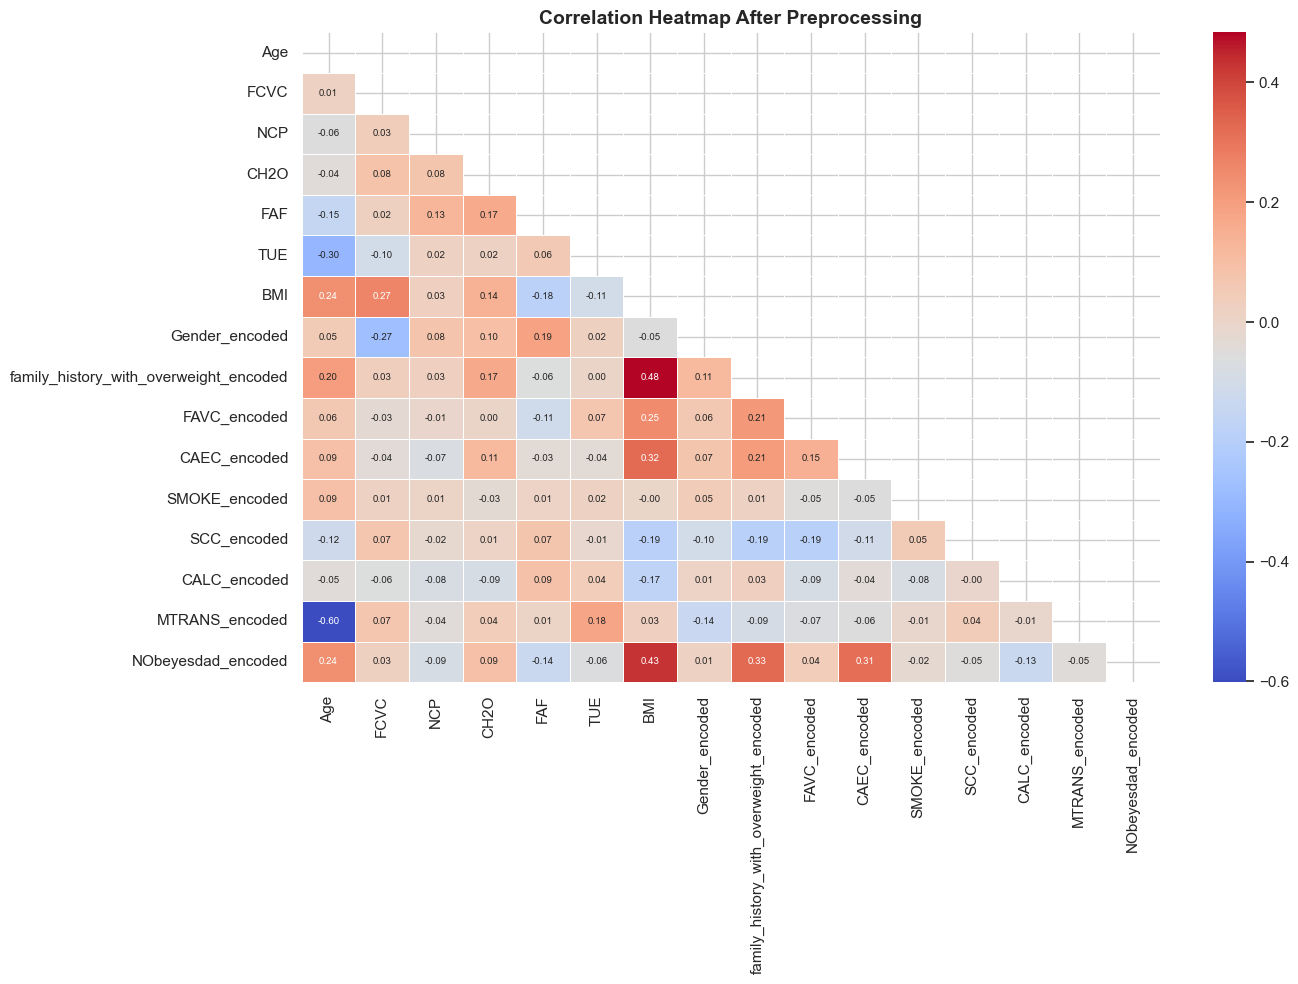

Insight: BMI and family history show strongest correlation with obesity level!


In [20]:
fig, ax = plt.subplots(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Correlation Heatmap After Preprocessing',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/prep_correlation_heatmap.png', dpi=150)
plt.show()
print('Insight: BMI and family history show strongest correlation with obesity level!')

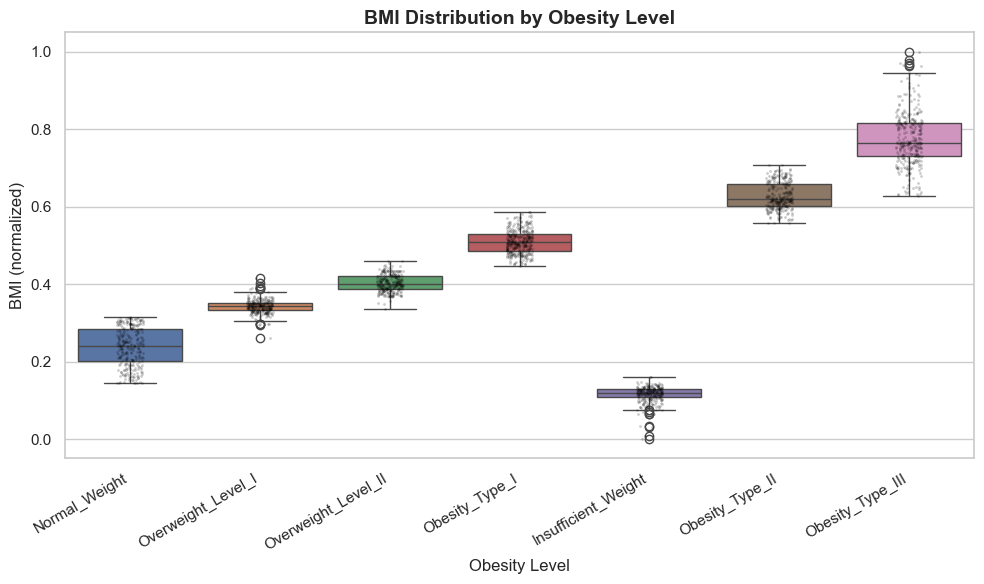

Insight: BMI is our strongest engineered feature — clearly separates classes!


In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_plot, x='Obesity Level', y='BMI',
            hue='Obesity Level', legend=False, ax=ax)
sns.stripplot(data=df_plot, x='Obesity Level', y='BMI',
              color='black', alpha=0.2, size=2, ax=ax)
ax.set_title('BMI Distribution by Obesity Level',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Obesity Level')
ax.set_ylabel('BMI (normalized)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/prep_bmi_by_class.png', dpi=150)
plt.show()
print('Insight: BMI is our strongest engineered feature — clearly separates classes!')

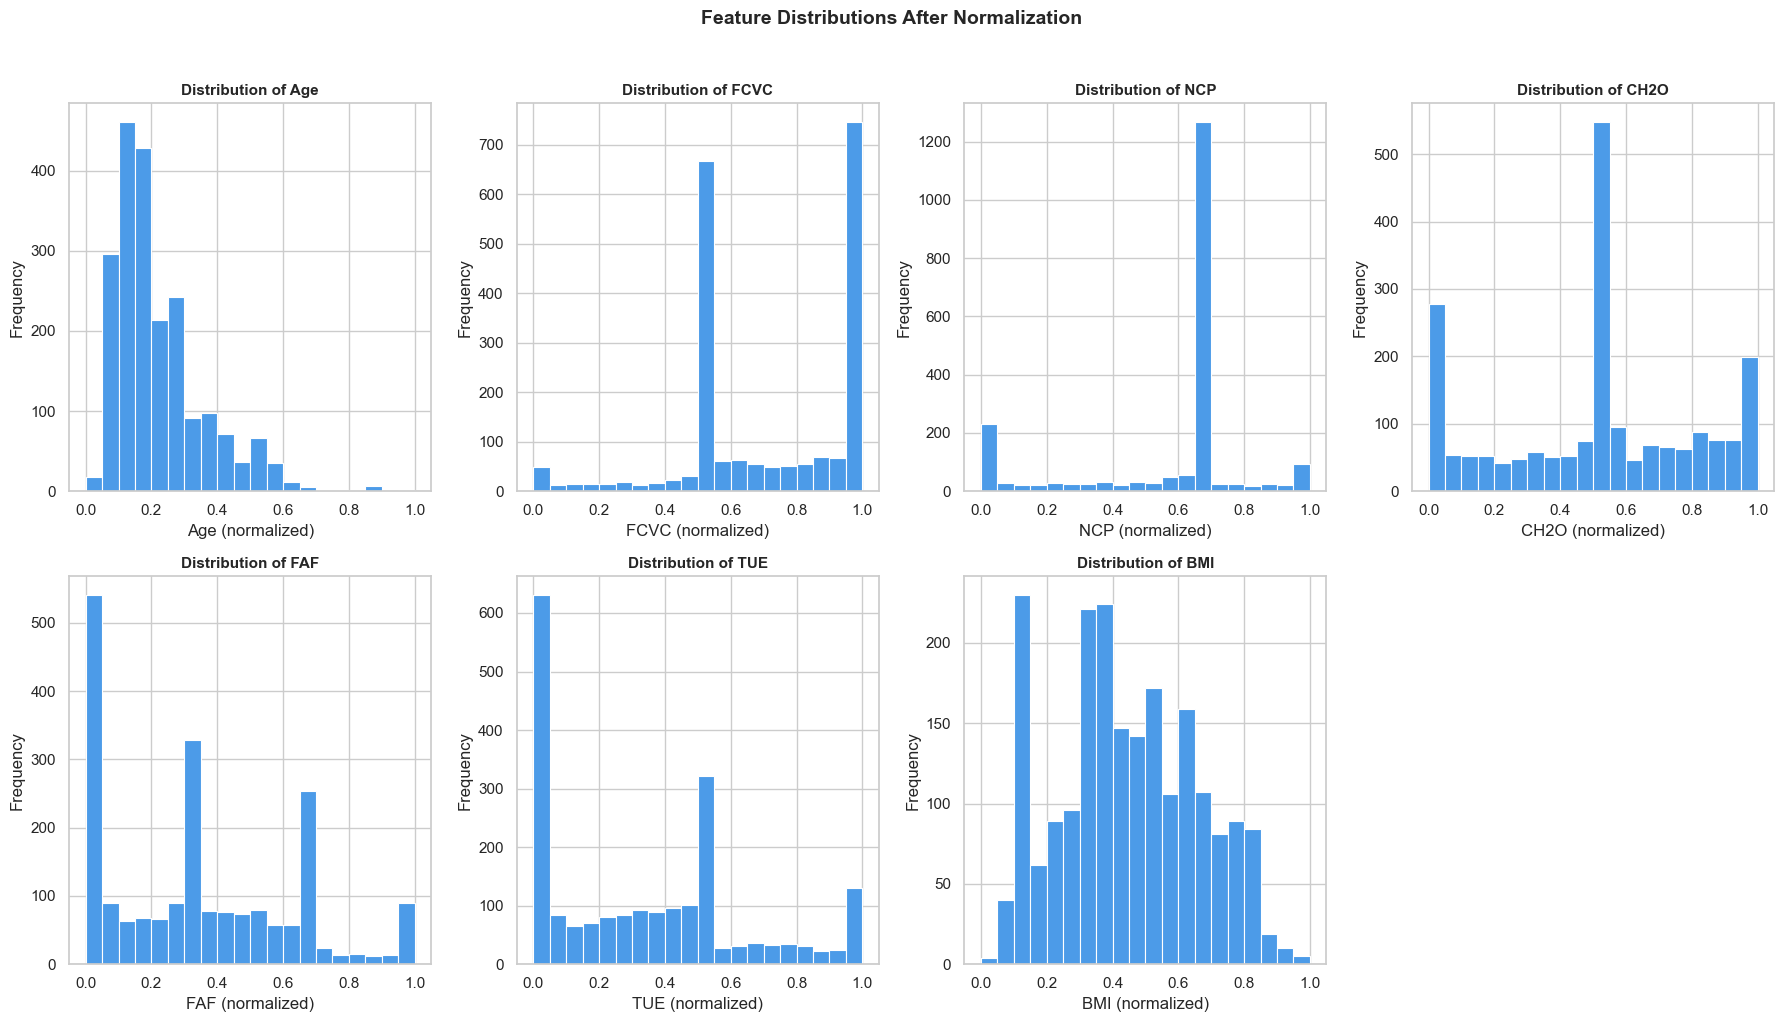

Insight: All features now scaled to [0,1] — ready for modeling!


In [22]:
features_to_plot = ['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    axes[i].hist(df[feature], bins=20,
                 color='#4C9BE8', edgecolor='white', linewidth=0.8)
    axes[i].set_title(f'Distribution of {feature}',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel(f'{feature} (normalized)')
    axes[i].set_ylabel('Frequency')

axes[7].set_visible(False)
plt.suptitle('Feature Distributions After Normalization',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/prep_feature_distributions.png', dpi=150)
plt.show()
print('Insight: All features now scaled to [0,1] — ready for modeling!')


## 7. Key Insights & Challenges

### 7.1 Preprocessing Summary

| Step | Action | Justification |
|---|---|---|
| Removed duplicates | 2,111 → 2,087 rows | Avoid model bias from repeated entries |
| Engineered BMI | Weight / Height² | Captures obesity risk in one meaningful ratio |
| Dropped Height & Weight | Reduced to 16 columns | BMI already captures both — removes redundancy |
| Label encoded 9 columns | Text → integers | ML algorithms require numerical input |
| Normalized 7 columns | Scale [0,1] | Prevents scale dominance in distance-based models |

### 7.2 Key Findings from EDA
- The dataset contains **7 well-balanced classes** (267–351 per class)
- **No missing values** found in any column
- **24 duplicate rows** identified and removed
- **Weight** shows the strongest relationship with obesity level
- **Age** is right-skewed — most participants are young adults
- **FAF** and **TUE** show skewed distributions

### 7.3 Strongest Predictors Identified
- **BMI** — engineered feature, strongest predictor
- **family_history_with_overweight** — strong correlation with obesity level
- **CAEC** — eating between meals
- **FAVC** — frequent consumption of high caloric food

### 7.4 Challenges
- Dataset contained 24 duplicate rows — removed to avoid bias
- Height and Weight combined into BMI to reduce redundancy
- Categorical variables required encoding before modeling
- Dataset is slightly synthetic — results may not fully generalize